In [1]:
# ИМПОРТИРУЕМ БИБЛИОТЕКИ:
import scipy
from scipy import integrate
import numpy as np
# from matplotlib import pyplot as plt
ingrt = scipy.integrate.quad # ingrt(функция, start, stop)[0], т.к. второе это тупо погрешность

In [2]:
# ОЪЯВЛЯЕМ И ИНИЦИАЛИЗИРУЕМ КОНСТАНТЫ/ПЕРЕМЕННЫЕ(параметры):

data = {
  #  толщина кристалла германия
  "tKristGe": 0.000000000566,
  
  # толщина кристалла кремния:
  "tKristSi": 0.00000000054307,

  # постоянная планка:
  "h": 6.62607015e-34, #  6,62607015 ⋅ 10⁻³⁴ Дж·с

  # постоянная больцмана:
  "Kb": 1.380649e-23, #  1,380 649⋅10⁻²³ Дж·К⁻¹

  # π:
  "p": np.pi,

  # скорость:
  "v": 334, #  334 м/с

  #vGe
  "vGe": 5400,

  # атомная масса Ge:
  "MjGe": 72.630,

  # атомная масса Si:
  "MjSi": 28.085,

  # ΘGe:
  "Ge": 360, #  360 Кельвинов

  # ΘSi:
  "Si": 645, #  645 Кельвинов

  # средняя атомная масса:
  "MSi": 72.630,

  # средняя атомная масса:
  "MGe": 28.085,

  # коэффициент Пуассона Ge:
  "viGe": 0.31,

  # коэффициент Пуассона Si
  "viSi": 0.28,

  # постоянная Грюнайзена Ge:
  "yGe": 1.046,  #  37638609

  #teplorjach
  "CGe": 23.32,

  #coef
  "coef": 0.625,

  # постоянная Грюнайзена Si:
  "ySi": 0.000037125, # неправельно но нам пофиг, не нужно

  # атомный объем Ge:
  "VjGe": 0.00001634,

  # атомный объем Si:
  "VjSi": 0.00001205,

  #Средний атомный объем Ge
  "bGe": 0.0136445613375916,

  #Средний атомный объем Si
  "bSi": 0.01205364806,

  # мат.константа
  "e": np.e,

  # лютый костыль
  "j": 0.002898,

  # скорость света в вакуме
  "c": 299792458
}

In [4]:
# ВЫЧИСЛЕНИЕ ДЛЯ...

# Si (кремния)
def computation_Si(arg_data, T):
  # λSi
  if T < 400:
    wwSi = T**3 # первые 400 Кельвинов
  elif T > 400 and T < 645:
    wwSi = (arg_data["e"] * arg_data["Si"]) / T # 400-645 Кельвинов
  else:
    wwSi = 1/T # 450-1000 Кельвинов
  # Волновой вектор Si
  kvSi = (2 * arg_data["p"]) / wwSi
  # Частота колебаний Ge
  wSi = arg_data["v"] * kvSi
  #Стандартная замена переменной
  x = (arg_data["h"] * wSi) / (arg_data["Kb"] * T)
  # скорость рассеяния фононов на поверхности Ge
  tBSi = 1/(arg_data["v"] / arg_data["tKristSi"])
  # скорость рассеяния на точечных дефектах Si
  #tPDGe = ((arg_data["bSi"] ** 3) * (wSi ** 4)) / (4 * arg_data["p"] * (arg_data["v"] ** 3))
  # скорость рассеяния в процессах переброса Si
  tUSi = 1/(arg_data["h"] * (arg_data["ySi"] ** 2) * T * (wSi ** 2) * (np.e ** (((-1 * arg_data["Si"]) / (3 * T)) / (arg_data["MSi"] * (arg_data["v"] ** 2) * arg_data["Si"]))))
  # время релаксации
  tCSi = 1/(1/tBSi + 1/tUSi) # + tPDSi 
  # модель Каллуэя для Si
  intgrl = ingrt(lambda x: ((x ** 4) * np.exp(x)) / ((np.exp(x) - 1) ** 2) * tCSi, 0, arg_data["Si"]/T)[0]
  t = arg_data["Kb"] / (2 * (arg_data["p"] ** 2) * arg_data["v"])
  kSi = intgrl*t*((arg_data["Kb"] * T / arg_data["h"]) ** 3)
  return kSi

# Ge (германия)
def computation_Ge(arg_data, T):
  
  alfa = arg_data["coef"] * T
  yGe = ((arg_data["vGe"] ** 2) *alfa) / arg_data["CGe"]
  # λGe
  if T < 250:
    wwGe = T**3 # первые 250 Кельвинов
  elif T < 450:
    wwGe = (arg_data["e"] * arg_data["Ge"]) / T # 250-450 Кельвинов
  else:
    wwGe = 1/T # 450-1000 Кельвинов
  # Волновой вектор Ge
  kvGe = (2 * arg_data["p"]) / ((wwGe * 2) / 4)
  # Частота колебаний Ge
  wGe = arg_data["v"] * kvGe
  #Стандартная замена переменной
  x = (arg_data["h"] * wGe) / (arg_data["Kb"] * T)
  
  #ee = arg_data["h"] * W ##energia fonona
  #x = T #arg_data["h"] * 
  W = (arg_data["Kb"] * T * x ) / arg_data["h"]
  # скорость рассеяния фононов на поверхности Ge
  tBGe = 1/(arg_data["v"] / arg_data["tKristGe"])
  # скорость рассеяния на точечных дефектах Ge
  #tPDGe = ((arg_data["bGe"] ** 3) * (wGe ** 4)) / (4 * arg_data["p"] * (arg_data["v"] ** 3))
  # скорость рассеяния в процессах переброса Ge
  tUGe = 1/(arg_data["h"] * (arg_data["yGe"] ** 2) * T * (W ** 2) * (np.e ** (((-1 * arg_data["Ge"]) / (3 * T)) / (arg_data["MGe"] * (arg_data["v"] ** 2) * arg_data["Ge"]))))
  # время релаксации
  tCGe = 1/(1/tBGe + 1/tUGe) # + tPDGe 
  # модель Каллуэя для Ge
  intgrl = ingrt(lambda x: ((x ** 4) * np.exp(x)) / ((np.exp(x) - 1) ** 2) * tCGe, 0, arg_data["Ge"]/T)[0]
  t = arg_data["Kb"] / (2 * (arg_data["p"] ** 2) * arg_data["v"])
  kGe = intgrl*t*((arg_data["Kb"] * T / arg_data["h"]) ** 3)

  return kGe

# СПЛАВА
#def computation_All(arg_data):
#  ySiGe = 0.000067
#  xjGe = 0.72
#  M = 59.68
#  V = 0.00001452
  # ε:
#  qwe = ((((4 + (6.4 * ySiGe)) * ( 1 + ( arg_data["viGe"] + (arg_data["viSi"] / 2)))) / ( 3 * (1 - arg_data["viGe"] + arg_data["viSi"]))) ** 2) * 2
#  Galloy = xjGe * ((((arg_data["MjGe"] - M) / M) ** 2) + (qwe * ((arg_data["VjGe"] - V) / V ** 2))
#  return 0 

print(computation_Ge(data, 1000))

0.4960605825540849


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:27: RuntimeWarning: overflow encountered in double_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:63: RuntimeWarning: overflow encountered in double_scalars


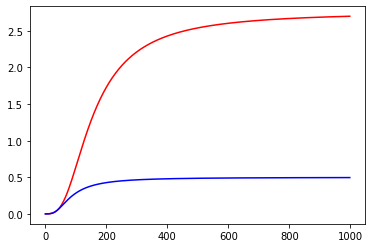

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
i = 1000
plt.plot([computation_Si(data, t)  for t in range(1, i)], "r") #  красный - кремний
# plt.plot([300], [6.02], 'ro')
# , 2, 3, 4      , 4, 9, 3
plt.plot([computation_Ge(data, t) for t in range(1, i)], "b") #  синий - германий
# plt.plot([300], [1.49], 'bo')
#         , 3, 3, 3                 , 4, 9, 3
#  !!!   / t **2   !!!
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:27: RuntimeWarning: overflow encountered in double_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:63: RuntimeWarning: overflow encountered in double_scalars


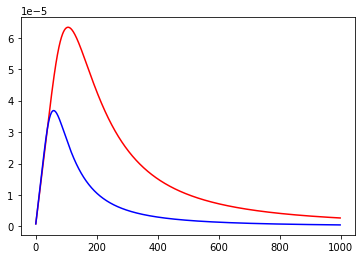

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
i = 1000
plt.plot([computation_Si(data, t)/t**2  for t in range(1, i)], "r") #  красный - кремний
# plt.plot([300], [6.02], 'ro')
# , 2, 3, 4      , 4, 9, 3
plt.plot([computation_Ge(data, t)/t**2 for t in range(1, i)], "b") #  синий - германий
# plt.plot([300], [1.49], 'bo')
#         , 3, 3, 3                 , 4, 9, 3
#  !!!   / t **2   !!!
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:27: RuntimeWarning: overflow encountered in double_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:63: RuntimeWarning: overflow encountered in double_scalars


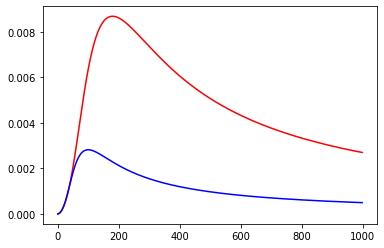

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
i = 1000
plt.plot([computation_Si(data, t)/t  for t in range(1, i)], "r") #  красный - кремний
# plt.plot([300], [6.02], 'ro')
# , 2, 3, 4      , 4, 9, 3
plt.plot([computation_Ge(data, t)/t for t in range(1, i)], "b") #  синий - германий
# plt.plot([300], [1.49], 'bo')
#         , 3, 3, 3                 , 4, 9, 3
#  !!!   / t **2   !!!
plt.show()

In [ ]:
# ВЫЧИСЛЯЕМ ВКЛЯД КАЖДОГО ПАРАМЕТРА

def RRRR(arg: str): #  вычисляем вклад аргумента
  # нужно просто менять название функции если надо вычислить 
  # зависимость для другово
  T = 300
  data_to_change = data.copy()
  data_to_change[arg] = data_to_change[arg] * 2 #  меняем данные путем умножения на 2
  vkl = abs(computation_Ge(data_to_change, T) - computation_Ge(data, T)) # модуль разницы функции с стандартной датой и новой с вариированным аргументом
  return vkl

#vklad: dict = {}

for ARG in data.keys():
  print(f"{ARG} => {RRRR(ARG)}")

tKristGe => 0.465102633655969
tKristSi => 0.0
h => 0.40696480444999006
Kb => 6.976539504828682
p => 0.3488269752428809
v => 0.3488269752428056
vGe => 0.0
MjGe => 0.0
MjSi => 0.0
Ge => 2.5793626619141463
Si => 0.0
MSi => 0.0
MGe => 0.0
viGe => 0.0
viSi => 0.0
yGe => 1.80855330711438e-12
CGe => 0.0
coef => 0.0
ySi => 0.0
VjGe => 0.0
VjSi => 0.0
bGe => 0.0
bSi => 0.0
e => 0.0
j => 0.0
c => 0.0


In [ ]:
def computation_Ge_Crist(T):
#T = 300 #(0;1000)
  Tdeb = 360
  c = 23.32
  v = 5400
  l = np.exp(Tdeb / T)
  k = (1/3) * c * v * l
  return k

In [ ]:
print(" T:           K:")
for i in range(1,400):
  print(str(i) + "   -   " + str(computation_Ge_Crist(i)))

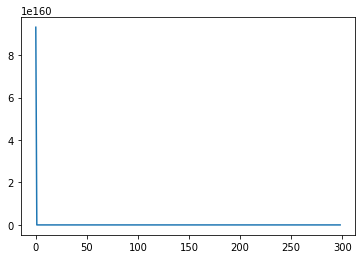

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot([computation_Ge_Crist(t) for t in range(1, 300)])

In [ ]:
# НЕ АКТУАЛЬНО !!!

# коэффициент рассеяния Ge:
GGe = GimpGe + GalloyGe

# коэффициент рассеяния Si:
GSi = GimpSi + GalloySi

# время релаксации Ge:
tCGe = tBGe + tPDGe + tUGe

# время релаксации
tCSi = Si = tBSi + tPDSi + tUSi

# скорость рассеяния фононов на поверхности Ge:
tBGe = v / tKristGe

# скорость рассеяния фононов на поверхности Si:
tBSi = v / tKristSi

# скорость рассеяния на точечных дефектах Ge:
PDGe = (b^3*GGe*ω^4)/(4*π*v^3) #(b^3*GGe*ω^4)/(4*π*v^3)

# скорость рассеяния на точечных дефектах Si:
tPDSi = (b^3*GSi*ω^4)/(4*π*v^3)

#ω (величин обратная времени релаксации):
w = 1 / tC

# *скоращение формулы*
x = (h * w) / (Kb * T) # x = hω/KbT


####################################

# kGe = (Kb / 2π^2*v)*(Kb*T / h)^3 0ΘGe ((x^4*e^x) / (e^x-1)^2) * tCGe*d*x
# T = переменная (0-400 Кельвинов)  (есть)



T = 34 #  для примера!!!

###################################

w = 1 #  ω   (ω = xKbT/h  некорректно) пока не выразили

h = 6.62607015 * (10 ** -34) #  Постоянная планка h Дж·с
Kb = 1.380649 * (10 ** -23) #  Постоянная больцмана Kb  (Дж·К⁻¹)
x = (h * w) / (Kb * T) #  НЕ ДО КОНЦА КОРРЕКТЕН
ΘGe = 360
tKristGe = 0.000000000566 #  толщина кристалла германия
v = 334
tBGe = v / tKristGe #  скорость рассеяния фононов на поверхности Ge
VjGe = 0.00001634 #  атомная масса Ge
MjGe = 72.630 #  атомный объем Ge
xjGe = 1
yGe = 0.0000972973 #  постоянная Грюнайзена Ge
viGe = 0.31 #  коэффициент Пуассона Ge
εGe = 2 * ((4 + (6.4 * yGe)) * (1 + viGe) / (3 * (1-viGe))) ** 2 #  2((4 + 6.4yGe)(1 + viGe)/(3(1-viGe)))^2
p = np.pi #  π
MGe = 28.085 #  средняя атомная масса
GalloyGe = xjGe * ((((MjGe - MGe) / MGe) ** 2) + (εGe * ((VjGe - VGe) / VGe) ** 2)) #  рассеяние на составляющих сплавов Ge
GimpGe = 0
GGe = GimpGe + GalloyGe #  коэффициент рассеяния Ge
bGe = 0.0136445613375916
tPDGe = ((bGe ** 3) * (GGe * (w ** 4))) / (4 * p * (v ** 3)) # скорость рассеяния на точечных дефектах Ge
tUGe = h * (yGe ** 2) * T * (w ** 2) * (exp((-1 * ΘGe) / (3 * T)) / (MGe * (v ** 2) * ΘGe)) #  скорость рассеяния в процессах переброса Ge
tCGe = tBGe + tPDGe + tUGe  # время релаксации Ge
kGe = (Kb / (2 * (p ** 2)) * v) * (((Kb * T) / h ) ** 3 ) * ingrt(((((x ** 4) * (e ** x)) / (((e ** x) - 1) ** 2)) * tCGe), 0, ΘGe)[0]
print(KGe)

NameError: ignored